In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import tp2_reconstruccion_3d.code_examples.charuco_example.aruco as aruco
import auxiliares
import importlib

In [2]:
# =========================================================
# 1. Parámetros del tablero checkerboard
# =========================================================
checkerboard = (10, 7)          # número de esquinas internas (puntos por fila, puntos por columna)
square_size_mm = 24.2           # tamaño del cuadrado en milímetros
square_size = square_size_mm / 1000.0  # convertir a metros (opcional, para coherencia 3D)


# =========================================================
# 2. Función para obtener puntos 3D del patrón
# =========================================================
def generar_puntos_objeto(checkerboard, square_size):
    """
    Genera las coordenadas 3D del patrón del checkerboard en el plano Z=0.
    """
    objp = np.zeros((checkerboard[0] * checkerboard[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
    objp *= square_size
    return objp


# =========================================================
# 3. Calibración estéreo
# =========================================================
def calibrar_stereo_checkerboard(base_dir, checkerboard, square_size):

    left_images = sorted(glob.glob(os.path.join(base_dir, "left*.jpg")))
    right_images = sorted(glob.glob(os.path.join(base_dir, "right*.jpg")))

    assert len(left_images) == len(right_images) and len(left_images) > 0, \
        "Debe haber el mismo número de imágenes left/right y al menos una pareja."

    # Criterio de terminación para cornerSubPix
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # Preparar puntos 3D del tablero
    objp = generar_puntos_objeto(checkerboard, square_size)

    objpoints = []   # puntos 3D reales en el mundo
    imgpointsL = []  # puntos 2D detectados en la cámara izquierda
    imgpointsR = []  # puntos 2D detectados en la cámara derecha

    print(f"Detectando checkerboard en {len(left_images)} pares de imágenes...")

    for left_path, right_path in zip(left_images, right_images):
        imgL = cv2.imread(left_path)
        imgR = cv2.imread(right_path)
        grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
        grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

        # Detectar esquinas del tablero
        retL, cornersL = cv2.findChessboardCorners(grayL, checkerboard, None)
        retR, cornersR = cv2.findChessboardCorners(grayR, checkerboard, None)

        if retL and retR:
            objpoints.append(objp)

            # Refinar las esquinas
            cornersL = cv2.cornerSubPix(grayL, cornersL, (11, 11), (-1, -1), criteria)
            cornersR = cv2.cornerSubPix(grayR, cornersR, (11, 11), (-1, -1), criteria)

            imgpointsL.append(cornersL)
            imgpointsR.append(cornersR)

    print(f"Se detectaron {len(objpoints)} pares válidos de imágenes para calibrar.")

    # Calibrar cámaras individuales
    retL, K1, d1, _, _ = cv2.calibrateCamera(objpoints, imgpointsL, grayL.shape[::-1], None, None)
    retR, K2, d2, _, _ = cv2.calibrateCamera(objpoints, imgpointsR, grayR.shape[::-1], None, None)

    # Calibración estéreo
    flags = cv2.CALIB_FIX_INTRINSIC
    criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)

    retS, K1, d1, K2, d2, R, T, E, F = cv2.stereoCalibrate(
        objpoints, imgpointsL, imgpointsR,
        K1, d1, K2, d2,
        grayL.shape[::-1],
        criteria=criteria_stereo,
        flags=flags
    )

    # Guardar resultados
    calib = {
        "left_K": K1, "left_dist": d1,
        "right_K": K2, "right_dist": d2,
        "R": R, "T": T, "E": E, "F": F
    }

    os.makedirs(base_dir, exist_ok=True)
    with open(os.path.join(base_dir, "stereo_calibration.pkl"), "wb") as f:
        pickle.dump(calib, f)

    print("\n✅ Calibración estéreo guardada en stereo_calibration.pkl")
    return calib


# =========================================================
# 4. Utilidad para imprimir matrices
# =========================================================
def np_print(name, arr):
    np.set_printoptions(precision=4, suppress=True)
    print(f"\n{name} =\n{arr}")


# =========================================================
# 5. Main
# =========================================================
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib"

calib = calibrar_stereo_checkerboard(base_dir, checkerboard, square_size)

print("\n### PARÁMETROS DE CALIBRACIÓN ESTÉREO ###")
np_print("Matriz intrínseca cámara izquierda (K1)", calib["left_K"])
np_print("Coef. distorsión izquierda (d1)", calib["left_dist"])
np_print("Matriz intrínseca cámara derecha (K2)", calib["right_K"])
np_print("Coef. distorsión derecha (d2)", calib["right_dist"])
np_print("Rotación (R)", calib["R"])
np_print("Traslación (T)", calib["T"])
np_print("Matriz esencial (E)", calib["E"])
np_print("Matriz fundamental (F)", calib["F"])


Detectando checkerboard en 21 pares de imágenes...
Se detectaron 20 pares válidos de imágenes para calibrar.

✅ Calibración estéreo guardada en stereo_calibration.pkl

### PARÁMETROS DE CALIBRACIÓN ESTÉREO ###

Matriz intrínseca cámara izquierda (K1) =
[[600.6263   0.     949.3032]
 [  0.     601.9213 541.4748]
 [  0.       0.       1.    ]]

Coef. distorsión izquierda (d1) =
[[ 0.0186 -0.0323 -0.0025 -0.0002  0.0059]]

Matriz intrínseca cámara derecha (K2) =
[[599.0856   0.     953.4288]
 [  0.     599.1282 524.4291]
 [  0.       0.       1.    ]]

Coef. distorsión derecha (d2) =
[[ 0.0151 -0.0312 -0.0025  0.0007  0.0054]]

Rotación (R) =
[[ 1.      0.0021 -0.0008]
 [-0.0021  0.9999  0.0129]
 [ 0.0008 -0.0129  0.9999]]

Traslación (T) =
[[-0.0605]
 [ 0.0009]
 [-0.0008]]

Matriz esencial (E) =
[[-0.      0.0008  0.0009]
 [-0.0008 -0.0008  0.0605]
 [-0.0008 -0.0605 -0.0008]]

Matriz fundamental (F) =
[[ 0.     -0.     -0.0051]
 [ 0.      0.     -1.8643]
 [ 0.0026  1.8166  1.    ]]


⚠️ 'image_size' no estaba en el pickle, se infirió como: (1920, 1080)
✅ Mapas de rectificación guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib/stereo_maps.pkl


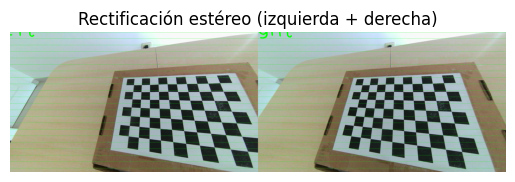

In [3]:
# =========================================================
# 1. Rutas y carga de calibración
# =========================================================
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib"
calib_file = os.path.join(base_dir, "stereo_calibration.pkl")

with open(calib_file, "rb") as f:
    calib = pickle.load(f)

# =========================================================
# 2. Extraer los parámetros
# =========================================================
left_K = calib["left_K"]
left_dist = calib["left_dist"]
right_K = calib["right_K"]
right_dist = calib["right_dist"]
R = calib["R"]
T = calib["T"]

# Inferir tamaño de imagen si no está guardado
if "image_size" in calib:
    image_size = tuple(calib["image_size"])
else:
    # Busca una imagen cualquiera con 'left' en el nombre
    sample_path = sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0]
    sample_img = cv2.imread(sample_path)
    image_size = (sample_img.shape[1], sample_img.shape[0])  # (w, h)
    print("⚠️ 'image_size' no estaba en el pickle, se infirió como:", image_size)

# =========================================================
# 3. Calcular la rectificación estéreo
# =========================================================
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist,
    right_K, right_dist,
    image_size,
    R, T,
    alpha=0,           # 0: recorte máximo, 1: sin recorte
    newImageSize=image_size
)

# =========================================================
# 4. Generar los mapas de rectificación
# =========================================================
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1
)

# =========================================================
# 5. Guardar los mapas
# =========================================================
stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
    "image_size": image_size
}

maps_file = os.path.join(base_dir, "stereo_maps.pkl")
with open(maps_file, "wb") as f:
    pickle.dump(stereo_maps, f)

print("✅ Mapas de rectificación guardados en:", maps_file)

# =========================================================
# 6. (Opcional) Visualización de prueba
# =========================================================
# Para verificar que la rectificación quedó alineada correctamente:
left_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0])
right_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*right*.jpg")))[0])

left_rect = cv2.remap(left_img, left_map_x, left_map_y, cv2.INTER_LINEAR)
right_rect = cv2.remap(right_img, right_map_x, right_map_y, cv2.INTER_LINEAR)

# Dibujar líneas horizontales para verificar la alineación epipolar
vis = np.hstack((left_rect, right_rect))
for y in range(0, vis.shape[0], 50):
    cv2.line(vis, (0, y), (vis.shape[1], y), (0, 255, 0), 1)

plt.imshow(vis[:, :, ::-1])  # Convertir BGR a RGB para matplotlib
plt.axis("off")
plt.title("Rectificación estéreo (izquierda + derecha)")
plt.show()


In [ ]:
importlib.reload(auxiliares)

auxiliares.rectificar_imagenes(
    path_imgs="tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures",
    path_maps="tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib/stereo_maps.pkl"
)


🔹 Rectificando 21 pares de imágenes...
   ROI común aplicado: (x=0, y=0, w=1920, h=1079)
✅ Imágenes rectificadas guardadas en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas


🔹 Mostrando 2 pares de imágenes rectificadas...


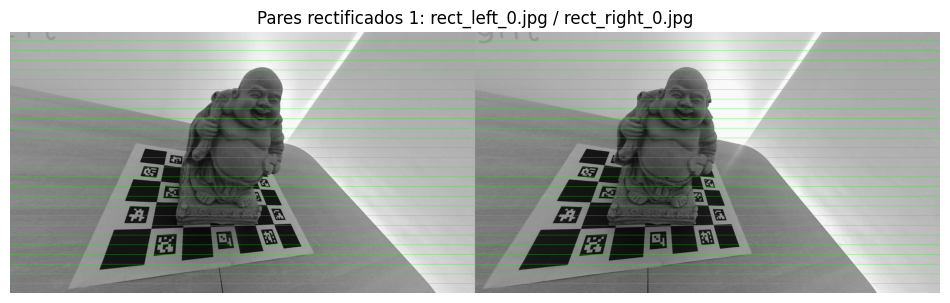

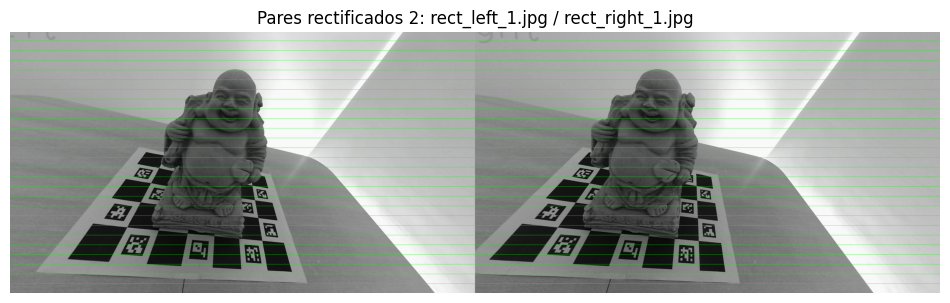

✅ Visualización completada.


In [5]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

def visualizar_rectificadas_plt(path_rectificadas, step=50):
    """
    Muestra dos pares de imágenes rectificadas lado a lado con líneas epipolares verdes.
    """
    left_imgs  = sorted(glob.glob(os.path.join(path_rectificadas, "rect_left_*.jpg")))
    right_imgs = sorted(glob.glob(os.path.join(path_rectificadas, "rect_right_*.jpg")))

    if len(left_imgs) == 0 or len(left_imgs) != len(right_imgs):
        print("⚠️ No se encontraron pares válidos en:", path_rectificadas)
        print(f"Left: {len(left_imgs)}, Right: {len(right_imgs)}")
        return

    n_pairs = min(2, len(left_imgs))
    print(f"🔹 Mostrando {n_pairs} pares de imágenes rectificadas...")

    for i in range(n_pairs):
        imgL = cv2.imread(left_imgs[i])
        imgR = cv2.imread(right_imgs[i])

        if imgL is None or imgR is None:
            print(f"❌ Error leyendo: {left_imgs[i]} o {right_imgs[i]}")
            continue

        # Convertir BGR → RGB para que matplotlib muestre colores correctos
        imgL = cv2.cvtColor(imgL, cv2.COLOR_BGR2RGB)
        imgR = cv2.cvtColor(imgR, cv2.COLOR_BGR2RGB)

        # Concatenar horizontalmente
        vis = np.hstack((imgL, imgR))

        # Dibujar líneas horizontales (epipolares)
        vis_lines = vis.copy()
        for y in range(0, vis.shape[0], step):
            vis_lines[y:y+1, :, :] = (0, 255, 0)  # línea verde fina

        # Mostrar
        plt.figure(figsize=(12, 5))
        plt.imshow(vis_lines)
        plt.title(f"Pares rectificados {i+1}: {os.path.basename(left_imgs[i])} / {os.path.basename(right_imgs[i])}")
        plt.axis("off")
        plt.show()

    print("✅ Visualización completada.")

# Ejemplo de uso:
visualizar_rectificadas_plt(
    path_rectificadas="tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas",
    step=40
)


In [ ]:
from pathlib import Path
from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import InputPair, Config


# Ruta base del modelo CREStereo
models_path = Path.home() / ".cache" / "stereodemo" / "models"


def procesar_imagenes_rectificadas(path_imgs, out_dir, metodo="cre"):
    """
    Procesa imágenes YA RECTIFICADAS con stereodemo.
    Guarda:
      - mapas de disparidad crudos (.npy)
      - mapas normalizados en gris (.png)
      - mapas colorizados (.png)
    """
    config = Config(models_path=models_path)
    
    # Selección del método
    if metodo == "cre":
        method = CREStereo(config)
    elif metodo == "bm":
        method = StereoBM(config)
    else:
        method = StereoSGBM(config)

    # Carpeta de salida
    out_dir = os.path.join(out_dir, f"disparidad_{metodo}")
    os.makedirs(out_dir, exist_ok=True)

    # Buscar imágenes rectificadas
    left_imgs = sorted(glob.glob(os.path.join(path_imgs, "rect_left_*.jpg")))
    right_imgs = sorted(glob.glob(os.path.join(path_imgs, "rect_right_*.jpg")))

    print(f"🔹 Encontradas {len(left_imgs)} imágenes izquierdas")
    print(f"🔹 Encontradas {len(right_imgs)} imágenes derechas\n")

    for i, (left_path, right_path) in enumerate(zip(left_imgs, right_imgs)):
        print(f"➡️  Procesando par {i+1}/{len(left_imgs)}: {os.path.basename(left_path)}")
        
        # Cargar imágenes
        imgL = cv2.imread(left_path)
        imgR = cv2.imread(right_path)
        
        if imgL is None or imgR is None:
            print(f"❌ Error cargando imágenes: {left_path} o {right_path}")
            continue
        
        # Crear InputPair sin calibración (ya están rectificadas)
        pair = InputPair(
            left_image=imgL, 
            right_image=imgR, 
            calibration=None,  
            status=os.path.basename(left_path)
        )
        
        # Calcular disparidad
        disparity = method.compute_disparity(pair)
        d = disparity.disparity_pixels.astype(np.float32)

        # Guardar valores crudos
        base = os.path.basename(left_path).replace("rect_left_", "").replace(".jpg", "")
        np.save(os.path.join(out_dir, f"disp_raw_{base}.npy"), d)

        # Normalización segura
        d_min, d_max = np.nanmin(d), np.nanmax(d)
        if np.isfinite(d_min) and np.isfinite(d_max) and d_max > d_min:
            dvis = 255 * (d - d_min) / (d_max - d_min)
        else:
            dvis = np.zeros_like(d)
        dvis = np.clip(dvis, 0, 255).astype("uint8")

        # Versión colorizada para visualización
        dvis_color = cv2.applyColorMap(dvis, cv2.COLORMAP_JET)

        # Guardar resultados
        cv2.imwrite(os.path.join(out_dir, f"disp_gray_{base}.png"), dvis)
        cv2.imwrite(os.path.join(out_dir, f"disp_color_{base}.png"), dvis_color)

        print(f"   ✅ Guardado: disp_color_{base}.png")

    cv2.destroyAllWindows()
    print(f"\n🎉 Procesamiento completado. Mapas guardados en: {out_dir}")

from pathlib import Path
models_dir = Path.home() / ".cache" / "stereodemo" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

path_imgs = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas"
out_dir   = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures"

# === Ejemplo de uso ===
procesar_imagenes_rectificadas(path_imgs, out_dir, metodo="cre")

🔹 Encontradas 21 imágenes izquierdas
🔹 Encontradas 21 imágenes derechas

➡️  Procesando par 1/21: rect_left_0.jpg


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


   ✅ Guardado: disp_color_0.png
➡️  Procesando par 2/21: rect_left_1.jpg
   ✅ Guardado: disp_color_1.png
➡️  Procesando par 3/21: rect_left_10.jpg
   ✅ Guardado: disp_color_10.png
➡️  Procesando par 4/21: rect_left_11.jpg
   ✅ Guardado: disp_color_11.png
➡️  Procesando par 5/21: rect_left_12.jpg
   ✅ Guardado: disp_color_12.png
➡️  Procesando par 6/21: rect_left_13.jpg
   ✅ Guardado: disp_color_13.png
➡️  Procesando par 7/21: rect_left_14.jpg
   ✅ Guardado: disp_color_14.png
➡️  Procesando par 8/21: rect_left_15.jpg
   ✅ Guardado: disp_color_15.png
➡️  Procesando par 9/21: rect_left_16.jpg
   ✅ Guardado: disp_color_16.png
➡️  Procesando par 10/21: rect_left_17.jpg
   ✅ Guardado: disp_color_17.png
➡️  Procesando par 11/21: rect_left_18.jpg
   ✅ Guardado: disp_color_18.png
➡️  Procesando par 12/21: rect_left_19.jpg
   ✅ Guardado: disp_color_19.png
➡️  Procesando par 13/21: rect_left_2.jpg
   ✅ Guardado: disp_color_2.png
➡️  Procesando par 14/21: rect_left_20.jpg
   ✅ Guardado: disp_color

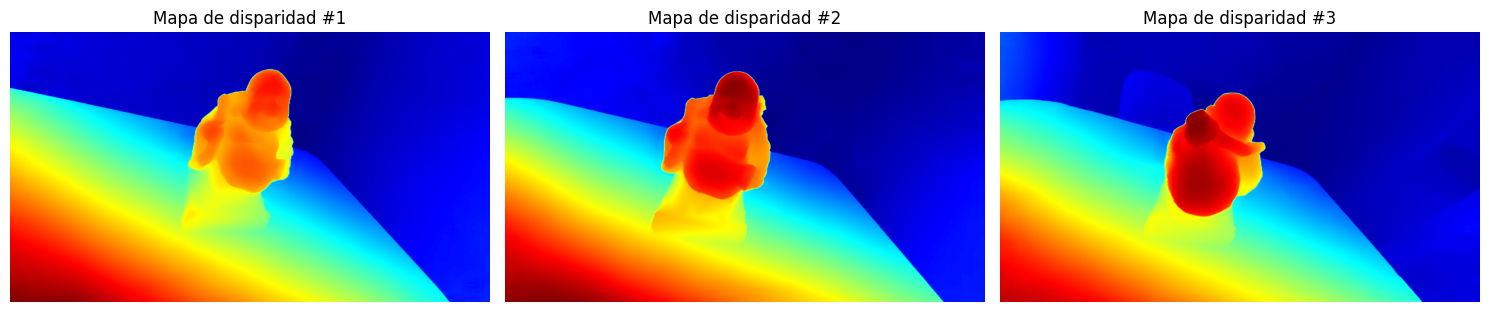

In [7]:
# Carpeta con las imágenes visuales
path_visual = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/disparidad_cre"

# Buscar mapas
disp_imgs = sorted(glob.glob(os.path.join(path_visual, "disp_color_*.png")))

# Mostrar algunos ejemplos
n = 3
fig, axes = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    disp = cv2.imread(disp_imgs[i])
    disp_rgb = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    axes[i].imshow(disp_rgb)
    axes[i].set_title(f"Mapa de disparidad #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import open3d as o3d

# %%
# =========================================================
# 1. Parámetros del tablero checkerboard (para calibración)
# =========================================================
checkerboard = (10, 7)
square_size_mm = 24.2
square_size = square_size_mm / 1000.0

# =========================================================
# Configuración del Charuco Board (PARÁMETROS ORIGINALES)
# =========================================================
DICTIONARY_TYPE = cv2.aruco.DICT_6X6_250
SQUARES_X = 5
SQUARES_Y = 7
SQUARE_LENGTH = 52.6  # mm
MARKER_LENGTH = 31.3  # mm

# Crear diccionario y board de Charuco
aruco_dict = cv2.aruco.getPredefinedDictionary(DICTIONARY_TYPE)
charuco_board = cv2.aruco.CharucoBoard(
    (SQUARES_X, SQUARES_Y),
    SQUARE_LENGTH / 1000.0,  # convertir a metros
    MARKER_LENGTH / 1000.0,  # convertir a metros
    aruco_dict
)

# %%
# =========================================================
# 2. Función para obtener puntos 3D del patrón
# =========================================================
def generar_puntos_objeto(checkerboard, square_size):
    objp = np.zeros((checkerboard[0] * checkerboard[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
    objp *= square_size
    return objp

# %%
# =========================================================
# 3. Calibración estéreo
# =========================================================
def calibrar_stereo_checkerboard(base_dir, checkerboard, square_size):
    left_images = sorted(glob.glob(os.path.join(base_dir, "left*.jpg")))
    right_images = sorted(glob.glob(os.path.join(base_dir, "right*.jpg")))

    assert len(left_images) == len(right_images) and len(left_images) > 0, \
        "Debe haber el mismo número de imágenes left/right y al menos una pareja."

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    objp = generar_puntos_objeto(checkerboard, square_size)

    objpoints = []
    imgpointsL = []
    imgpointsR = []

    print(f"Detectando checkerboard en {len(left_images)} pares de imágenes...")

    for left_path, right_path in zip(left_images, right_images):
        imgL = cv2.imread(left_path)
        imgR = cv2.imread(right_path)
        grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
        grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

        retL, cornersL = cv2.findChessboardCorners(grayL, checkerboard, None)
        retR, cornersR = cv2.findChessboardCorners(grayR, checkerboard, None)

        if retL and retR:
            objpoints.append(objp)
            cornersL = cv2.cornerSubPix(grayL, cornersL, (11, 11), (-1, -1), criteria)
            cornersR = cv2.cornerSubPix(grayR, cornersR, (11, 11), (-1, -1), criteria)
            imgpointsL.append(cornersL)
            imgpointsR.append(cornersR)

    print(f"Se detectaron {len(objpoints)} pares válidos de imágenes para calibrar.")

    retL, K1, d1, _, _ = cv2.calibrateCamera(objpoints, imgpointsL, grayL.shape[::-1], None, None)
    retR, K2, d2, _, _ = cv2.calibrateCamera(objpoints, imgpointsR, grayR.shape[::-1], None, None)

    flags = cv2.CALIB_FIX_INTRINSIC
    criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)

    retS, K1, d1, K2, d2, R, T, E, F = cv2.stereoCalibrate(
        objpoints, imgpointsL, imgpointsR,
        K1, d1, K2, d2,
        grayL.shape[::-1],
        criteria=criteria_stereo,
        flags=flags
    )

    calib = {
        "left_K": K1, "left_dist": d1,
        "right_K": K2, "right_dist": d2,
        "R": R, "T": T, "E": E, "F": F
    }

    os.makedirs(base_dir, exist_ok=True)
    with open(os.path.join(base_dir, "stereo_calibration.pkl"), "wb") as f:
        pickle.dump(calib, f)

    print("\n✅ Calibración estéreo guardada en stereo_calibration.pkl")
    return calib

# %%
# =========================================================
# 4. Calcular rectificación
# =========================================================
def calcular_rectificacion(base_dir):
    calib_file = os.path.join(base_dir, "stereo_calibration.pkl")
    
    with open(calib_file, "rb") as f:
        calib = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    right_K = calib["right_K"]
    right_dist = calib["right_dist"]
    R = calib["R"]
    T = calib["T"]
    
    if "image_size" in calib:
        image_size = tuple(calib["image_size"])
    else:
        sample_path = sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0]
        sample_img = cv2.imread(sample_path)
        image_size = (sample_img.shape[1], sample_img.shape[0])
        print("⚠️ 'image_size' no estaba en el pickle, se infirió como:", image_size)
    
    R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
        left_K, left_dist,
        right_K, right_dist,
        image_size,
        R, T,
        alpha=0,
        newImageSize=image_size
    )
    
    left_map_x, left_map_y = cv2.initUndistortRectifyMap(
        left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1
    )
    right_map_x, right_map_y = cv2.initUndistortRectifyMap(
        right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1
    )
    
    stereo_maps = {
        "left_map_x": left_map_x,
        "left_map_y": left_map_y,
        "right_map_x": right_map_x,
        "right_map_y": right_map_y,
        "R1": R1,
        "R2": R2,
        "P1": P1,
        "P2": P2,
        "Q": Q,
        "validRoi1": validRoi1,
        "validRoi2": validRoi2,
        "image_size": image_size
    }
    
    maps_file = os.path.join(base_dir, "stereo_maps.pkl")
    with open(maps_file, "wb") as f:
        pickle.dump(stereo_maps, f)
    
    print("✅ Mapas de rectificación guardados en:", maps_file)
    
    # Visualización
    left_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0])
    right_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*right*.jpg")))[0])
    
    left_rect = cv2.remap(left_img, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_rect = cv2.remap(right_img, right_map_x, right_map_y, cv2.INTER_LINEAR)
    
    vis = np.hstack((left_rect, right_rect))
    for y in range(0, vis.shape[0], 50):
        cv2.line(vis, (0, y), (vis.shape[1], y), (0, 255, 0), 1)
    
    plt.figure(figsize=(15, 8))
    plt.imshow(vis[:, :, ::-1])
    plt.axis("off")
    plt.title("Rectificación estéreo (izquierda + derecha)")
    plt.show()

# %%
# =========================================================
# 5. Rectificar imágenes
# =========================================================
def rectificar_imagenes(path_imgs, path_maps):
    output_dir = os.path.join(path_imgs, "rectificadas")
    os.makedirs(output_dir, exist_ok=True)
    
    with open(path_maps, "rb") as f:
        maps = pickle.load(f)
    
    left_map_x, left_map_y = maps["left_map_x"], maps["left_map_y"]
    right_map_x, right_map_y = maps["right_map_x"], maps["right_map_y"]
    validRoi1 = maps.get("validRoi1", (0, 0, left_map_x.shape[1], left_map_x.shape[0]))
    validRoi2 = maps.get("validRoi2", (0, 0, right_map_x.shape[1], right_map_x.shape[0]))
    
    def _intersect_roi(r1, r2):
        x1, y1, w1, h1 = r1
        x2, y2, w2, h2 = r2
        xa, ya = max(x1, x2), max(y1, y2)
        xb, yb = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
        if xb <= xa or yb <= ya:
            return (0, 0, left_map_x.shape[1], left_map_x.shape[0])
        return (xa, ya, xb - xa, yb - ya)
    
    roiX, roiY, roiW, roiH = _intersect_roi(validRoi1, validRoi2)
    
    left_imgs = sorted(glob.glob(os.path.join(path_imgs, "left_*.jpg")))
    right_imgs = sorted(glob.glob(os.path.join(path_imgs, "right_*.jpg")))
    
    if len(left_imgs) != len(right_imgs):
        print("⚠️ Cantidad distinta de imágenes left/right")
        return
    
    print(f"🔹 Rectificando {len(left_imgs)} pares de imágenes...")
    print(f"   ROI común aplicado: (x={roiX}, y={roiY}, w={roiW}, h={roiH})")
    
    for left_path, right_path in zip(left_imgs, right_imgs):
        imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
        imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)
        
        rectL = cv2.remap(imgL, left_map_x, left_map_y, cv2.INTER_LINEAR)
        rectR = cv2.remap(imgR, right_map_x, right_map_y, cv2.INTER_LINEAR)
        
        rectL = rectL[roiY:roiY+roiH, roiX:roiX+roiW]
        rectR = rectR[roiY:roiY+roiH, roiX:roiX+roiW]
        
        baseL = os.path.basename(left_path)
        baseR = os.path.basename(right_path)
        outL = os.path.join(output_dir, f"rect_{baseL}")
        outR = os.path.join(output_dir, f"rect_{baseR}")
        
        cv2.imwrite(outL, rectL)
        cv2.imwrite(outR, rectR)
    
    print(f"✅ Imágenes rectificadas guardadas en: {output_dir}")

# %%
# =========================================================
# 6. NUEVA FUNCIÓN: Detección de marcadores Charuco
# =========================================================
def detect_charuco_markers(image, board, detector_params=None):
    """
    Detecta marcadores Charuco en una imagen dado un tablero.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image

    if not detector_params:
        detector_params = cv2.aruco.DetectorParameters()
        # Parámetros más permisivos
        detector_params.adaptiveThreshWinSizeMin = 3
        detector_params.adaptiveThreshWinSizeMax = 23
        detector_params.adaptiveThreshWinSizeStep = 10
        detector_params.minMarkerPerimeterRate = 0.03
        detector_params.maxMarkerPerimeterRate = 4.0

    detector = cv2.aruco.ArucoDetector(board.getDictionary(), detector_params)
    corners, ids, rejected = detector.detectMarkers(gray)

    if ids is None or len(ids) == 0:
        return None

    # Ordenar por ID
    ids = ids.flatten()
    order = np.argsort(ids)
    ids = ids[order]
    corners = [corners[i] for i in order]

    result = {
        'corners': corners,
        'ids': ids,
        'rejected': rejected
    }

    return result

# %%
# =========================================================
# 7. NUEVA FUNCIÓN: Estimación de pose con homografía
# =========================================================
def estimate_camera_pose_with_homography(image, board, detection, calibration, undistort=False):
    """
    Estima la pose de la cámara usando homografía y PnP.
    """
    corners = detection['corners']
    ids = detection['ids']
    K, dist = calibration

    if len(ids) < 4:
        return None

    # Construir correspondencias 2D (imagen) <-> 2D (plano del board)
    image_points = []
    board_points = []

    board_ids = board.getIds()
    points3d = board.getObjPoints()
    
    for corner, id in zip(corners, ids):
        id = int(id)
        if id not in board_ids:
            continue

        point3d = points3d[id]  # (4, 3)
        image_points.extend(corner[0])  # (4, 2)
        board_points.extend(point3d)

    image_points = np.array(image_points, dtype=np.float32)
    board_points = np.array(board_points, dtype=np.float32)

    if len(image_points) < 4:
        return None

    if undistort:
        use_image_points = cv2.undistortPoints(
            image_points.reshape(-1, 1, 2), K, dist, P=K
        ).reshape(-1, 2)
    else:
        use_image_points = image_points

    # Estimar homografía
    H, inliers = cv2.findHomography(
        board_points[:, :2],
        use_image_points,
        method=cv2.LMEDS
    )

    if H is None:
        return None

    # Obtener todas las esquinas Charuco en el plano del board
    charuco_obj_points = []
    chess = board.getChessboardCorners()
    for i in range(chess.shape[0]):
        corner = chess[i]
        charuco_obj_points.append(corner)

    charuco_board_points = np.array(
        [p[:2] for p in charuco_obj_points], 
        dtype=np.float32
    ).reshape(-1, 1, 2)

    # Proyectar puntos usando la homografía
    projected_charuco_corners = cv2.perspectiveTransform(charuco_board_points, H)
    projected_charuco_corners = projected_charuco_corners.reshape(-1, 2)

    obj_pts = np.array(charuco_obj_points, dtype=np.float32)

    if undistort:
        use_image_points = cv2.undistortPoints(
            projected_charuco_corners.reshape(-1, 1, 2), K, dist, P=K
        ).reshape(-1, 2)
    else:
        use_image_points = projected_charuco_corners

    # Resolver pose usando PnP con IPPE (ideal para planos)
    success, rvec, tvec = cv2.solvePnP(
        obj_pts,
        use_image_points,
        K,
        dist,
        flags=cv2.SOLVEPNP_IPPE
    )

    if not success:
        return None

    return success, rvec, tvec

# %%
# =========================================================
# 8. NUEVA FUNCIÓN: Detección completa de Charuco con pose
# =========================================================
def detect_charuco_pose(image, camera_matrix, dist_coeffs, board, verbose=False):
    """
    Detecta el Charuco board y calcula la pose usando homografía.
    """
    detection = detect_charuco_markers(image, board)
    
    if detection is None:
        if verbose:
            print("  ❌ No se detectaron marcadores ArUco")
        return False, None, None, None, None
    
    if verbose:
        print(f"  📍 Marcadores ArUco detectados: {len(detection['ids'])}")
    
    result = estimate_camera_pose_with_homography(
        image, board, detection, (camera_matrix, dist_coeffs), undistort=False
    )
    
    if result is None:
        if verbose:
            print(f"  ❌ No se pudo estimar la pose")
        return False, None, None, None, None
    
    success, rvec, tvec = result
    
    if verbose:
        print(f"  ✅ Pose estimada correctamente")
        print(f"     Traslación: {tvec.flatten()}")
    
    return success, rvec, tvec, detection['corners'], detection['ids']

# %%
# =========================================================
# 9. NUEVA FUNCIÓN: Dibujar marcadores Charuco
# =========================================================
def draw_charuco_markers(image, detection, draw_rejected=False):
    """
    Dibuja los resultados de la detección sobre la imagen.
    """
    output_image = image.copy()

    if detection is None:
        return output_image

    corners = detection["corners"]
    ids = detection["ids"]
    rejected = detection["rejected"]

    # Dibujar marcadores aceptados (verdes)
    if ids is not None and len(ids) > 0:
        output_image = cv2.aruco.drawDetectedMarkers(output_image, corners, ids)

    # Dibujar rechazados (rojos)
    if draw_rejected and rejected is not None and len(rejected) > 0:
        cv2.aruco.drawDetectedMarkers(
            output_image, rejected, borderColor=(0, 0, 255)
        )

    return output_image

# %%
# =========================================================
# 10. NUEVA FUNCIÓN: Visualizar detección de Charuco
# =========================================================
def visualizar_deteccion_charuco(image_path, camera_matrix, dist_coeffs, board):
    """
    Visualiza la detección de Charuco en una imagen con detalles completos.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ No se pudo cargar: {image_path}")
        return
    
    # Detectar marcadores
    detection = detect_charuco_markers(img, board)
    
    # Dibujar marcadores
    img_markers = draw_charuco_markers(img, detection, draw_rejected=True)
    
    if detection is None:
        print(f"❌ No se detectaron marcadores ArUco en {os.path.basename(image_path)}")
    else:
        print(f"✅ Detectados {len(detection['ids'])} marcadores ArUco")
        
        # Intentar estimar pose
        result = estimate_camera_pose_with_homography(
            img, board, detection, (camera_matrix, dist_coeffs), undistort=False
        )
        
        if result is not None:
            success, rvec, tvec = result
            if success:
                # Dibujar ejes de coordenadas
                axis_length = SQUARE_LENGTH / 1000.0 * 2  # 2 cuadrados de longitud
                cv2.drawFrameAxes(img_markers, camera_matrix, dist_coeffs, 
                                rvec, tvec, axis_length, thickness=3)
                print(f"✅ Pose estimada correctamente")
                print(f"   Traslación (x, y, z): ({tvec[0][0]:.3f}, {tvec[1][0]:.3f}, {tvec[2][0]:.3f}) m")
            else:
                print(f"❌ No se pudo estimar la pose")
        else:
            print(f"⚠️ Insuficientes marcadores para estimar pose")
    
    # Mostrar
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img_markers, cv2.COLOR_BGR2RGB))
    title = f"Detección Charuco - {os.path.basename(image_path)}"
    if detection is not None and result is not None:
        title += " ✅"
    else:
        title += " ❌"
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# %%
# =========================================================
# 11. NUEVA FUNCIÓN: Visualizar todas las detecciones
# =========================================================
def visualizar_todas_detecciones_charuco(base_dir, calib_path, max_images=5):
    """
    Visualiza la detección de Charuco en múltiples imágenes
    """
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    
    left_imgs = sorted(glob.glob(os.path.join(base_dir, "left_*.jpg")))
    
    print(f"🔍 Visualizando detección de Charuco en {min(max_images, len(left_imgs))} imágenes...\n")
    
    for i, img_path in enumerate(left_imgs[:max_images]):
        print(f"\n{'='*60}")
        print(f"Imagen {i+1}: {os.path.basename(img_path)}")
        print(f"{'='*60}")
        visualizar_deteccion_charuco(img_path, left_K, left_dist, charuco_board)

# %%
# =========================================================
# 12. Filtrado mejorado de puntos 3D
# =========================================================
def filtrar_puntos_3d_mejorado(points_3d, disparity, max_distance=2.0):
    """
    Filtrado más agresivo de puntos outliers
    """
    mask = disparity > disparity.min()
    
    # Filtrar valores finitos
    mask &= np.isfinite(points_3d[:, :, 0])
    mask &= np.isfinite(points_3d[:, :, 1])
    mask &= np.isfinite(points_3d[:, :, 2])
    
    # Filtrar por distancia razonable
    distances = np.linalg.norm(points_3d, axis=2)
    mask &= (distances < max_distance) & (distances > 0.01)
    
    # Filtrar coordenadas Z anómalas
    mask &= (points_3d[:, :, 2] > 0) & (points_3d[:, :, 2] < max_distance)
    
    return mask

# %%
# =========================================================
# 13. Crear matriz de transformación
# =========================================================
def create_transform_matrix(rvec, tvec):
    """
    Crea matriz de transformación homogénea 4x4 a partir de rvec y tvec.
    """
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[0:3, 0:3] = R
    T[0:3, 3] = tvec.flatten()
    return T

# %%
# =========================================================
# 13.5 NUEVA FUNCIÓN: Convertir a escala de grises
# =========================================================
def convertir_a_escala_grises(point_cloud):
    """
    Convierte los colores RGB de una nube de puntos a escala de grises
    usando la fórmula estándar de luminancia.
    
    Args:
        point_cloud: o3d.geometry.PointCloud con colores
    
    Returns:
        point_cloud: misma nube con colores en escala de grises
    """
    if not point_cloud.has_colors():
        print("⚠️ La nube no tiene colores para convertir")
        # Pintar de gris uniforme si no tiene colores
        point_cloud.paint_uniform_color([0.5, 0.5, 0.5])
        return point_cloud
    
    colors = np.asarray(point_cloud.colors)
    
    # Fórmula estándar de luminancia: Y = 0.299R + 0.587G + 0.114B
    gray_values = 0.299 * colors[:, 0] + 0.587 * colors[:, 1] + 0.114 * colors[:, 2]
    
    # Crear colores en escala de grises (mismo valor en R, G, B)
    gray_colors = np.column_stack([gray_values, gray_values, gray_values])
    
    point_cloud.colors = o3d.utility.Vector3dVector(gray_colors)
    
    print(f"✅ Nube convertida a escala de grises: {len(gray_colors)} puntos")
    
    return point_cloud

# %%
# =========================================================
# 14. FUNCIÓN PRINCIPAL: Reconstrucción 3D mejorada (EN ESCALA DE GRISES)
# =========================================================
def reconstruccion_3d_completa(max_distance=2.0, voxel_size=0.001):
    """
    Pipeline completo de reconstrucción 3D con transformación a coordenadas mundiales
    """
    base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco"
    calib_path = os.path.join(base_dir, "calib/stereo_calibration.pkl")
    maps_path = os.path.join(base_dir, "calib/stereo_maps.pkl")
    
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    with open(maps_path, "rb") as f:
        maps = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    Q = maps["Q"]
    
    captures_dir = os.path.join(base_dir, "captures")
    disparity_dir = os.path.join(captures_dir, "disparidad_cre")
    
    left_imgs_original = sorted(glob.glob(os.path.join(captures_dir, "left_*.jpg")))
    
    # Lista para acumular todas las nubes de puntos
    all_point_clouds = []
    successful_reconstructions = 0
    
    print("🔹 Iniciando reconstrucción 3D completa...")
    print(f"   Parámetros: max_distance={max_distance}m, voxel_size={voxel_size}m\n")
    
    for i, left_img_path in enumerate(left_imgs_original):
        print(f"\n{'='*60}")
        print(f"Procesando imagen {i+1}/{len(left_imgs_original)}: {os.path.basename(left_img_path)}")
        print(f"{'='*60}")
        
        left_img_original = cv2.imread(left_img_path)
        if left_img_original is None:
            print(f"❌ Error cargando imagen: {left_img_path}")
            continue
        
        success, rvec, tvec, corners, ids = detect_charuco_pose(
            left_img_original, left_K, left_dist, charuco_board, verbose=True
        )
        
        if not success:
            print(f"❌ No se pudo detectar Charuco en: {os.path.basename(left_img_path)}")
            continue
        
        print(f"✅ Charuco detectado, calculando transformaciones...")
        
        # C_T_O: Transformación de coordenadas del board (Origin) a cámara (Camera)
        C_T_O = create_transform_matrix(rvec, tvec)
        
        # Para transformar puntos de cámara a mundo, necesitamos la inversa
        O_T_C = np.linalg.inv(C_T_O)
        
        # ✨ CONVERSIÓN DE SISTEMA DE COORDENADAS: OpenCV → Open3D
        # OpenCV: X→derecha, Y→abajo, Z→adelante
        # Open3D: X→derecha, Y→arriba, Z→adentro (hacia la cámara)
        R_flip = np.array([
            [1,  0,  0],
            [0, -1,  0],  # Invertir Y
            [0,  0, -1]   # Invertir Z
        ])
        
        T_flip = np.eye(4)
        T_flip[:3, :3] = R_flip
        
        # Aplicar corrección de ejes DESPUÉS de la transformación mundo
        O_T_C_corrected = T_flip @ O_T_C
        
        # 🔍 DEBUG: Verificar orientación
        R_world, _ = cv2.Rodrigues(rvec)
        det_R = np.linalg.det(R_world)
        z_axis = R_world[:, 2]  # Eje Z del sistema del board
        
        print(f"   🔍 DEBUG Pose:")
        print(f"      det(R) = {det_R:.4f} (debe ser ~1.0)")
        print(f"      tvec = {tvec.flatten()}")
        print(f"      eje Z del board = {z_axis}")
        
        base_name = os.path.basename(left_img_path).replace("left_", "").replace(".jpg", "")
        disp_path = os.path.join(disparity_dir, f"disp_raw_{base_name}.npy")
        
        if not os.path.exists(disp_path):
            print(f"❌ No existe mapa de disparidad: {disp_path}")
            continue
        
        disparity = np.load(disp_path)
        points_3d = cv2.reprojectImageTo3D(disparity, Q)
        
        # Filtrado mejorado
        mask = filtrar_puntos_3d_mejorado(points_3d, disparity, max_distance)
        valid_points = points_3d[mask]
        
        if len(valid_points) == 0:
            print(f"❌ No hay puntos 3D válidos después del filtrado")
            continue
        
        print(f"   📊 Puntos válidos después de filtrado: {len(valid_points)}")
        
        # =========================================================
        # NUEVO BLOQUE: Asignar colores reales a cada punto
        # =========================================================
        img_left_color = cv2.imread(left_img_path)  # Imagen color original
        img_left_color = cv2.cvtColor(img_left_color, cv2.COLOR_BGR2RGB)

        # Asegurar que la imagen color tenga el mismo tamaño que la disparidad
        if img_left_color.shape[:2] != disparity.shape:
            img_left_color = cv2.resize(img_left_color, (disparity.shape[1], disparity.shape[0]), interpolation=cv2.INTER_LINEAR)

        # Aplanar y asociar los colores válidos según la máscara
        colors = img_left_color.reshape(-1, 3) / 255.0
        valid_colors = colors[mask.flatten()]  
        
        # =========================================================
        
        point_cloud = o3d.geometry.PointCloud()
        point_cloud.points = o3d.utility.Vector3dVector(valid_points)
        point_cloud.colors = o3d.utility.Vector3dVector(valid_colors)
        
        # Transformar a coordenadas mundiales con corrección de ejes
        points_camera = np.array(point_cloud.points)
        points_camera_homogeneous = np.column_stack([points_camera, np.ones(len(points_camera))])
        
        # Aplicar transformación con corrección de ejes OpenCV → Open3D
        points_world_homogeneous = (O_T_C_corrected @ points_camera_homogeneous.T).T
        points_world = points_world_homogeneous[:, :3] / points_world_homogeneous[:, 3:4]
        
        # Aplicar la transformación
        point_cloud.points = o3d.utility.Vector3dVector(points_world)
        
        # Filtrar outliers estadísticos
        cl, ind = point_cloud.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
        point_cloud = point_cloud.select_by_index(ind)
        
        # Downsample
        point_cloud = point_cloud.voxel_down_sample(voxel_size=voxel_size)
        
        # Verificar que la nube tiene colores
        print(f"   🎨 Puntos con color: {len(point_cloud.colors) if point_cloud.has_colors() else 'SIN COLOR'}")
        
        # Agregar a la lista (en lugar de usar +=)
        all_point_clouds.append(point_cloud)
        successful_reconstructions += 1
        
        print(f"✅ Nube de puntos procesada: {len(point_cloud.points)} puntos")
    
    if len(all_point_clouds) == 0:
        print("\n❌ No se generaron puntos 3D")
        return None
    
    # Combinar todas las nubes de puntos preservando colores
    print(f"\n🔗 Combinando {len(all_point_clouds)} nubes de puntos...")
    point_cloud_combined = o3d.geometry.PointCloud()

    all_points = []
    all_colors = []

    for pc in all_point_clouds:
        pts = np.asarray(pc.points)
        all_points.append(pts)

        if pc.has_colors() and len(pc.colors) == len(pc.points):
            all_colors.append(np.asarray(pc.colors))
        else:
            # Relleno gris si no había color en esta nube (mantiene alineación)
            all_colors.append(np.full((pts.shape[0], 3), 0.7, dtype=np.float64))

    combined_points = np.vstack(all_points)
    combined_colors = np.vstack(all_colors)

    point_cloud_combined.points = o3d.utility.Vector3dVector(combined_points)
    point_cloud_combined.colors = o3d.utility.Vector3dVector(combined_colors)

    print(f"   ✅ Puntos combinados: {len(combined_points)}")
    print(f"   ✅ Colores combinados: {len(combined_colors)}")
    
    print(f"\n{'='*60}")
    print(f"🎉 Reconstrucción completada")
    print(f"   Imágenes procesadas exitosamente: {successful_reconstructions}/{len(left_imgs_original)}")
    print(f"   Total de puntos: {len(point_cloud_combined.points)}")
    print(f"   Tiene colores: {point_cloud_combined.has_colors()}")
    print(f"{'='*60}\n")
    
    # =========================================================
    # CONVERTIR A ESCALA DE GRISES ✨
    # =========================================================
    print("🔍 Convirtiendo a escala de grises...")
    point_cloud_gray = o3d.geometry.PointCloud(point_cloud_combined)
    point_cloud_gray = convertir_a_escala_grises(point_cloud_gray)
    
    # =========================================================
    # VISUALIZACIÓN 3D EN ESCALA DE GRISES (ESTILO SIMPLE) ✨
    # =========================================================
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.1, origin=[0, 0, 0]
    )

    print("🔍 Abriendo visualizador 3D en escala de grises...")
    
    # Visualización simple (estilo draw_geometries)
    o3d.visualization.draw_geometries(
        [point_cloud_gray, coordinate_frame],
        window_name="Reconstrucción 3D (escala de grises)",
        width=1280,
        height=720,
        point_show_normal=False
    )
    
    # =========================================================
    # EXPORTAR NUBE FINAL (en escala de grises)
    # =========================================================
    output_path = os.path.join(base_dir, "reconstruccion_3d_final_grises.ply")
    o3d.io.write_point_cloud(output_path, point_cloud_gray, write_ascii=False)
    print(f"💾 Nube de puntos en escala de grises guardada en: {output_path}")
    
    return point_cloud_gray


# %%
# =========================================================
# 15. FUNCIÓN: Calcular centro robusto ignorando outliers
# =========================================================
def calcular_centro_robusto(points, percentile_range=(5, 95)):
    """
    Calcula el centro de la nube de puntos ignorando outliers
    usando percentiles en lugar de min/max
    
    Args:
        points: numpy array de puntos (N, 3)
        percentile_range: tupla (min_percentile, max_percentile)
    
    Returns:
        centro: numpy array (3,) con el centro robusto
    """
    min_p, max_p = percentile_range
    
    # Calcular límites usando percentiles para ignorar outliers
    x_min = np.percentile(points[:, 0], min_p)
    x_max = np.percentile(points[:, 0], max_p)
    y_min = np.percentile(points[:, 1], min_p)
    y_max = np.percentile(points[:, 1], max_p)
    z_min = np.percentile(points[:, 2], min_p)
    z_max = np.percentile(points[:, 2], max_p)
    
    centro = np.array([
        (x_min + x_max) / 2,
        (y_min + y_max) / 2,
        (z_min + z_max) / 2
    ])
    
    print(f"\n🎯 Centro calculado (robusto con percentiles {min_p}-{max_p}):")
    print(f"   X: {centro[0]:.4f} (rango: {x_min:.4f} a {x_max:.4f})")
    print(f"   Y: {centro[1]:.4f} (rango: {y_min:.4f} a {y_max:.4f})")
    print(f"   Z: {centro[2]:.4f} (rango: {z_min:.4f} a {z_max:.4f})")
    
    return centro


# %%
# =========================================================
# 16. FUNCIÓN: Bounding box basado en percentiles
# =========================================================
def crear_bounding_box_percentil(points, percentile=95, margin_factor=1.2):
    """
    Crea un bounding box basado en percentiles para ignorar outliers
    
    Args:
        points: numpy array de puntos (N, 3)
        percentile: percentil para definir los límites (95 ignora el 5% de outliers)
        margin_factor: factor de margen adicional (1.2 = 20% más grande)
    
    Returns:
        center, extent: centro y extensión del bounding box
    """
    # Calcular centro robusto
    center = calcular_centro_robusto(points, percentile_range=(100-percentile, percentile))
    
    # Calcular dimensiones usando percentiles
    min_p = 100 - percentile
    max_p = percentile
    
    width_x = np.percentile(points[:, 0], max_p) - np.percentile(points[:, 0], min_p)
    width_y = np.percentile(points[:, 1], max_p) - np.percentile(points[:, 1], min_p)
    width_z = np.percentile(points[:, 2], max_p) - np.percentile(points[:, 2], min_p)
    
    # Aplicar margen
    extent = [
        width_x * 0.4 / 2,
        width_y * 0.4 / 2,
        width_z * 0.6 / 2
    ]
    
    print(f"\n📦 Dimensiones del bounding box (con margen {margin_factor}x):")
    print(f"   Ancho  (X): {width_x:.4f} m → extent: {extent[0]:.4f} m")
    print(f"   Alto   (Y): {width_y:.4f} m → extent: {extent[1]:.4f} m")
    print(f"   Fondo  (Z): {width_z:.4f} m → extent: {extent[2]:.4f} m")
    
    return center, extent


# %%
# =========================================================
# 17. Filtrado por bounding box (MEJORADO)
# =========================================================
def crear_bounding_box_filtro(center, extent):
    """
    Crea un bounding box orientado para filtrar puntos con color rojo
    """
    bbox = o3d.geometry.OrientedBoundingBox(center, np.eye(3), extent)
    bbox.color = [1.0, 0.0, 0.0]  # ✨ Rojo brillante
    return bbox

def filtrar_por_bounding_box(point_cloud, center, extent):
    """
    Filtra puntos dentro de un bounding box preservando colores.
    """
    bbox = crear_bounding_box_filtro(center, extent)

    idx = bbox.get_point_indices_within_bounding_box(point_cloud.points)
    idx = np.asarray(idx, dtype=np.int64)

    filtered_pc = o3d.geometry.PointCloud()

    pts = np.asarray(point_cloud.points)
    if idx.size == 0:
        print("⚠️ El bbox no contiene puntos.")
        return filtered_pc, bbox

    filtered_pts = pts[idx]
    filtered_pc.points = o3d.utility.Vector3dVector(filtered_pts)

    # Copiar colores solo si existen y están alineados
    if point_cloud.has_colors():
        cols = np.asarray(point_cloud.colors)
        if cols.shape[0] == pts.shape[0]:
            filtered_cols = cols[idx]
            filtered_pc.colors = o3d.utility.Vector3dVector(filtered_cols)
        else:
            print("⚠️ Los colores no coinciden en longitud con los puntos. Pintando uniforme.")
            filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])
    else:
        print("⚠️ La nube original no tenía colores. Pintando uniforme.")
        filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])

    return filtered_pc, bbox


# %%
# =========================================================
# 18. Análisis de calidad de detecciones
# =========================================================
def analizar_calidad_detecciones():
    """
    Analiza todas las imágenes y reporta la calidad de detección
    """
    print("\n" + "=" * 80)
    print("ANÁLISIS DE CALIDAD DE DETECCIÓN")
    print("=" * 80)
    
    base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco"
    calib_path = os.path.join(base_dir, "calib/stereo_calibration.pkl")
    
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    
    captures_dir = os.path.join(base_dir, "captures")
    left_imgs = sorted(glob.glob(os.path.join(captures_dir, "left_*.jpg")))
    
    resultados = []
    
    for img_path in left_imgs:
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        success, rvec, tvec, corners, ids = detect_charuco_pose(
            img, left_K, left_dist, charuco_board, verbose=False
        )
        
        # Contar marcadores detectados
        num_markers = len(ids) if ids is not None else 0
        
        resultados.append({
            'imagen': os.path.basename(img_path),
            'exito': success,
            'num_marcadores': num_markers,
            'tvec': tvec.flatten() if tvec is not None else None
        })
    
    # Imprimir tabla de resultados
    print(f"\n{'Imagen':<15} {'Estado':<10} {'Marcadores':<12} {'Posición (x, y, z)'}")
    print("-" * 80)
    
    exitos = 0
    for r in resultados:
        estado = "✅ OK" if r['exito'] else "❌ FALLO"
        if r['exito']:
            exitos += 1
            pos = f"({r['tvec'][0]:.3f}, {r['tvec'][1]:.3f}, {r['tvec'][2]:.3f})"
        else:
            pos = "N/A"
        
        print(f"{r['imagen']:<15} {estado:<10} {r['num_marcadores']:<12} {pos}")
    
    print("-" * 80)
    print(f"\n📊 RESUMEN:")
    print(f"   Total de imágenes: {len(resultados)}")
    print(f"   Detecciones exitosas: {exitos}")
    print(f"   Detecciones fallidas: {len(resultados) - exitos}")
    print(f"   Tasa de éxito: {100 * exitos / len(resultados):.1f}%")
    
    return resultados

# %%
# =========================================================
# ANÁLISIS DE CALIDAD COMPLETO
# =========================================================
resultados_deteccion = analizar_calidad_detecciones()

# %%
# =========================================================
# RECONSTRUCCIÓN 3D CON PARÁMETROS AJUSTABLES
# =========================================================
print("\n" + "=" * 80)
print("PASO 2: RECONSTRUCCIÓN 3D COMPLETA")
print("=" * 80)

# Ejecutar reconstrucción con filtrado mejorado
point_cloud_final = reconstruccion_3d_completa(
    max_distance=2.0,    # Máxima distancia en metros desde la cámara
    voxel_size=0.001     # Tamaño de voxel para downsampling (1mm)
)

# %%
# =========================================================
# FILTRADO POR BOUNDING BOX CON MÉTODO AUTOMÁTICO ✨ (ESCALA DE GRISES)
# =========================================================

if point_cloud_final is not None and len(point_cloud_final.points) > 0:
    print("\n" + "=" * 80)
    print("PASO 3: FILTRADO POR BOUNDING BOX (MÉTODO AUTOMÁTICO)")
    print("=" * 80)
    
    # Estadísticas de la nube de puntos
    print("\n📊 Estadísticas de la nube de puntos:")
    print(f"   Total de puntos: {len(point_cloud_final.points)}")
    
    points = np.asarray(point_cloud_final.points)
    print(f"   Rango X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
    print(f"   Rango Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
    print(f"   Rango Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")
    
    # Calcular bounding box automático
    print("\n🎯 Calculando bounding box automático con percentiles...")
    center, extent = crear_bounding_box_percentil(
        points, 
        percentile=99,
    )
    
    offset = np.array([0.0, 0.0, 0.0])
    center_final = center + offset
    
    print(f"\n🔲 Aplicando bounding box automático:")
    print(f"   Centro: [{center_final[0]:.4f}, {center_final[1]:.4f}, {center_final[2]:.4f}]")
    print(f"   Extensión: [{extent[0]:.4f}, {extent[1]:.4f}, {extent[2]:.4f}]")
    
    # Filtrar puntos
    filtered_pc, bbox = filtrar_por_bounding_box(point_cloud_final, center_final, extent)
    
    print(f"\n📦 Puntos después de filtrado: {len(filtered_pc.points)}")
    print(f"   Porcentaje retenido: {100 * len(filtered_pc.points) / len(points):.1f}%")
    
    # Crear sistema de coordenadas
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.1, origin=[0, 0, 0]
    )

    # ✨ VISUALIZACIÓN SIMPLE EN ESCALA DE GRISES
    print("\n🔍 Visualizando nube filtrada en escala de grises...")
    
    o3d.visualization.draw_geometries(
        [filtered_pc, bbox, coordinate_frame],
        window_name="Nube filtrada (escala de grises con bbox rojo)",
        width=1280,
        height=720,
        point_show_normal=False
    )

    # Exportar versión filtrada en escala de grises
    output_filtered = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_filtrada_grises.ply"
    o3d.io.write_point_cloud(output_filtered, filtered_pc, write_ascii=False)
    print(f"💾 Nube de puntos filtrada en escala de grises guardada en: {output_filtered}")


ANÁLISIS DE CALIDAD DE DETECCIÓN

Imagen          Estado     Marcadores   Posición (x, y, z)
--------------------------------------------------------------------------------
left_0.jpg      ✅ OK       7            (0.099, 0.023, 0.530)
left_1.jpg      ✅ OK       7            (0.100, 0.055, 0.497)
left_10.jpg     ✅ OK       9            (-0.250, 0.139, 0.205)
left_11.jpg     ✅ OK       7            (-0.368, 0.062, 0.295)
left_12.jpg     ✅ OK       8            (-0.396, 0.014, 0.430)
left_13.jpg     ✅ OK       7            (-0.359, -0.030, 0.448)
left_14.jpg     ✅ OK       7            (-0.392, -0.057, 0.528)
left_15.jpg     ✅ OK       6            (-0.316, -0.056, 0.639)
left_16.jpg     ✅ OK       7            (-0.249, -0.054, 0.677)
left_17.jpg     ✅ OK       7            (-0.176, -0.043, 0.650)
left_18.jpg     ✅ OK       8            (-0.101, 0.001, 0.596)
left_19.jpg     ✅ OK       7            (0.056, 0.053, 0.544)
left_2.jpg      ✅ OK       8            (0.100, 0.090, 0.492)
left_